### Importação das Bibliotecas

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import polars as pl
import pandas as pd
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 50)

from sklearn.preprocessing import StandardScaler
import hdbscan
import umap

c:\Users\guilh\OneDrive\MBA\projeto_tcc\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load da base e criação de colunas adicionais

In [41]:
df = pd.read_parquet('dados/tabela_final.parquet')
df = df.fillna(0)
df['obitos_fora_estabelecimento'] = df['total_obitos'] - df['obitos_em_estabelecimentos']
df['taxa_obitos_fora_estabelecimento'] = (df['obitos_fora_estabelecimento'] / df['total_obitos']) * 100

### Análise exploratória dos dados

In [22]:
print("Primeiras 5 linhas do DataFrame:")
display(df.head())
print("\n" + "-"*50 + "\n")

print("Informações sobre o DataFrame (tipos de dados, valores não nulos):")
print(df.info())
print("\n" + "-"*50 + "\n")

print("Contagem de valores ausentes por coluna:")
print(df.isnull().sum())
print("\n" + "-"*50 + "\n")

print("Estatísticas descritivas básicas para todas as colunas:")

# Exibir estatísticas descritivas em blocos de colunas
cols = df.columns
chunk_size = 2

for i in range(0, len(cols), chunk_size):
    subset_cols = cols[i:i + chunk_size]
    print(f"\nEstatísticas descritivas para colunas {i+1} a {i+len(subset_cols)}:")
    print(df[subset_cols].describe(percentiles=[0.25,0.5,0.75,0.95,0.99]))

print("\n" + "-"*50 + "\n")

print("\n" + "-"*50 + "\n")
print(f"Total de linhas: {len(df)}")
print(f"Total de colunas: {len(df.columns)}")

Primeiras 5 linhas do DataFrame:


,populacao,idh,qtd_unidades,hab_por_unidade,unidades_por_k_hab,medicos_por_k_habitante,habitantes_por_medico,enfermeiros_por_k_habitante,habitantes_por_enfermeiros,leitos_existentes,quantidade_unidades_com_leito,quantidade_unidades_com_leito_por_k_hab,total_leitos_unidade,leitos_por_k_hab,leitos_sus,total_leitos_sus_unidade,leitos_sus_por_k_hab,obitos_por_unidade,obitos_em_estabelecimentos,total_obitos,taxa_mortalidade_geral,mortalidade_infantil,area_territorial,densidade_demografica,matriculas_ensino_medio,total_receitas_brutas,total_despesas_brutas,pib_per_capita,taxa_de_alfabetizados,taxa_de_nao_alfabetizados,pct_coleta_lixo,pct_com_rede_esgoto,pct_sem_rede_esgoto,media_anos_estudo_geral,media_anos_estudo_11_14,media_anos_estudo_15_17,media_anos_estudo_18_24,media_anos_estudo_25_mais,taxa_adultos_sem_instrucao,taxa_adultos_fundamental_completo,taxa_adultos_medio_completo,taxa_adultos_superior_completo,pct_idoso,taxa_pop_residente_favela,taxa_populacao_urbana,taxa_populacao_rural,taxa_freq_escolar,obitos_fora_estabelecimento,taxa_obitos_fora_estabelecimento
0,114559.0,0.675,70,1245.21,0.611039,4.320918,231.432323,1.091141,916.472000,96.0,2,0.017458,1.37,0.837996,82.0,1.17,0.715788,5.40,378.0,580,5.06,17.30,201.528,568.45,95.9,6.483341e+08,5.785557e+08,46196.74,94.36,5.64,94.28,95.26,4.74,9.4,5.8,8.4,10.9,9.5,29.00,18.69,44.59,7.72,11.63,0.069309,98.01,1.99,27.31,202.0,34.827586
1,10023.0,0.582,13,668.20,1.297017,1.995411,501.150000,2.095181,477.285714,1.0,1,0.099771,0.08,0.099771,0.0,0.00,0.000000,0.00,0.0,15,1.50,6.94,14011.695,0.72,76.7,1.227961e+08,1.029503e+08,16497.32,79.97,20.03,44.75,56.51,43.49,6.9,4.5,7.0,8.5,6.9,50.16,14.80,26.81,8.25,9.89,0.000000,42.55,57.45,26.05,15.0,100.0
2,21613.0,0.698,32,514.60,1.480590,2.359691,423.784314,0.971637,1029.190476,33.0,1,0.046268,1.03,1.526859,29.0,0.91,1.341785,1.09,35.0,97,4.49,2.33,4909.842,4.41,96.0,1.632065e+08,1.623077e+08,39325.43,92.74,7.26,80.57,90.09,9.90,8.7,6.2,9.0,10.9,8.5,40.24,16.85,30.53,12.38,15.91,0.000000,81.43,18.57,28.27,62.0,63.917526
3,31701.0,0.624,28,609.63,0.883253,1.482603,674.489362,1.293335,773.195122,38.0,1,0.031545,1.36,1.198700,38.0,1.36,1.198700,3.39,95.0,156,4.92,9.87,854.362,37.10,98.4,1.409138e+08,1.521446e+08,16694.97,77.71,22.29,92.04,86.86,13.14,7.6,6.1,8.9,11.2,7.1,47.57,14.49,29.81,8.13,15.33,0.000000,60.90,39.10,24.04,61.0,39.102564
4,12669.0,0.709,15,745.24,1.183992,3.078380,324.846154,1.815455,550.826087,30.0,1,0.078933,2.00,2.367985,25.0,1.67,1.973321,4.27,64.0,87,6.87,13.33,145.332,87.17,97.3,8.009879e+07,7.818575e+07,23824.33,95.53,4.47,97.38,90.01,9.99,8.5,6.1,9.7,11.6,8.1,39.73,19.20,32.55,8.53,14.85,0.000000,90.66,9.34,25.05,23.0,26.436782



--------------------------------------------------

Informações sobre o DataFrame (tipos de dados, valores não nulos):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5569 entries, 0 to 5568
Data columns (total 49 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   populacao                                5569 non-null   float64
 1   idh                                      5569 non-null   float64
 2   qtd_unidades                             5569 non-null   int64  
 3   hab_por_unidade                          5569 non-null   float64
 4   unidades_por_k_hab                       5569 non-null   float64
 5   medicos_por_k_habitante                  5569 non-null   float64
 6   habitantes_por_medico                    5569 non-null   float64
 7   enfermeiros_por_k_habitante              5569 non-null   float64
 8   habitantes_por_enfermeiros               5569 non-null   float64
 9 

In [23]:
# Análise do conteudo de cada coluna
for col in df.columns:
    print(df[col].value_counts(), '\n', '-'*50)	

populacao
4127.0     4
2946.0     4
5228.0     4
4841.0     4
6566.0     3
          ..
3791.0     1
2838.0     1
8047.0     1
4787.0     1
32150.0    1
Name: count, Length: 5068, dtype: int64 
 --------------------------------------------------
idh
0.710    43
0.592    41
0.701    38
0.725    37
0.718    36
         ..
0.507     1
0.813     1
0.486     1
0.483     1
0.511     1
Name: count, Length: 350, dtype: int64 
 --------------------------------------------------
qtd_unidades
6      280
7      260
8      259
5      253
9      248
      ... 
134      1
427      1
910      1
216      1
474      1
Name: count, Length: 454, dtype: int64 
 --------------------------------------------------
hab_por_unidade
351.08     3
712.00     3
421.00     3
631.00     3
921.00     3
          ..
897.33     1
731.55     1
531.89     1
1008.25    1
293.71     1
Name: count, Length: 5314, dtype: int64 
 --------------------------------------------------
unidades_por_k_hab
2.941176    3
1.014199    3
1

In [15]:
for col in df.columns:
    if df[df[col] == 'nan'].shape[0] > 0:
        print(f"A coluna {col} possui valores 'nan'.")
    elif df[df[col] == 'NaN'].shape[0] > 0:
        print(f"A coluna {col} possui valores 'NaN'.")
    elif df[df[col] == 'NAN'].shape[0] > 0:
        print(f"A coluna {col} possui valores 'NAN'.")
    elif df[df[col].isna()].shape[0] > 0:
        print(f"A coluna {col} possui valores 'NaN'.")

In [11]:
# Análise por UF
pl.DataFrame(df).group_by('uf').agg(
    pl.col('idh').mean().alias('idh_medio'),
    pl.col('qtd_unidades').sum().alias('qtd_unidades'),
    pl.col('leitos_existentes').sum().alias('leitos_existentess'),
    pl.col('leitos_sus').sum().alias('leitos_sus'),
    pl.col('total_obitos').sum().alias('total_obitos'),
    pl.col('taxa_mortalidade_geral').mean().alias('taxa_mortalidade_g'),
    pl.col('mortalidade_infantil').mean().alias('mortalidade_infantil')
).sort('total_obitos', descending=True).head(10)

uf,idh_medio,qtd_unidades,leitos_existentess,leitos_sus,total_obitos,taxa_mortalidade_g,mortalidade_infantil
str,f64,i64,f64,f64,i64,f64,f64
"""SP""",0.739607,85396,112714.0,64041.0,355239,5.508059,11.145093
"""MG""",0.667878,51720,49094.0,32903.0,162013,5.122356,12.025346
"""RJ""",0.708913,28248,45993.0,24395.0,150536,7.669891,12.826304
"""BA""",0.593904,20258,33983.0,26297.0,107185,6.118489,14.815779
"""RS""",0.712095,32996,33674.0,22489.0,103934,6.356217,11.609537
"""PR""",0.70196,30349,30448.0,20789.0,90065,5.393233,11.684912
"""PE""",0.596249,10722,26977.0,19318.0,72221,5.169297,13.754054
"""CE""",0.61663,14042,22452.0,17106.0,64738,5.922663,12.032935
"""SC""",0.726688,22678,17765.0,12570.0,51300,4.970983,10.320915



--- Calculando e Plotando Matriz de Correlação ---


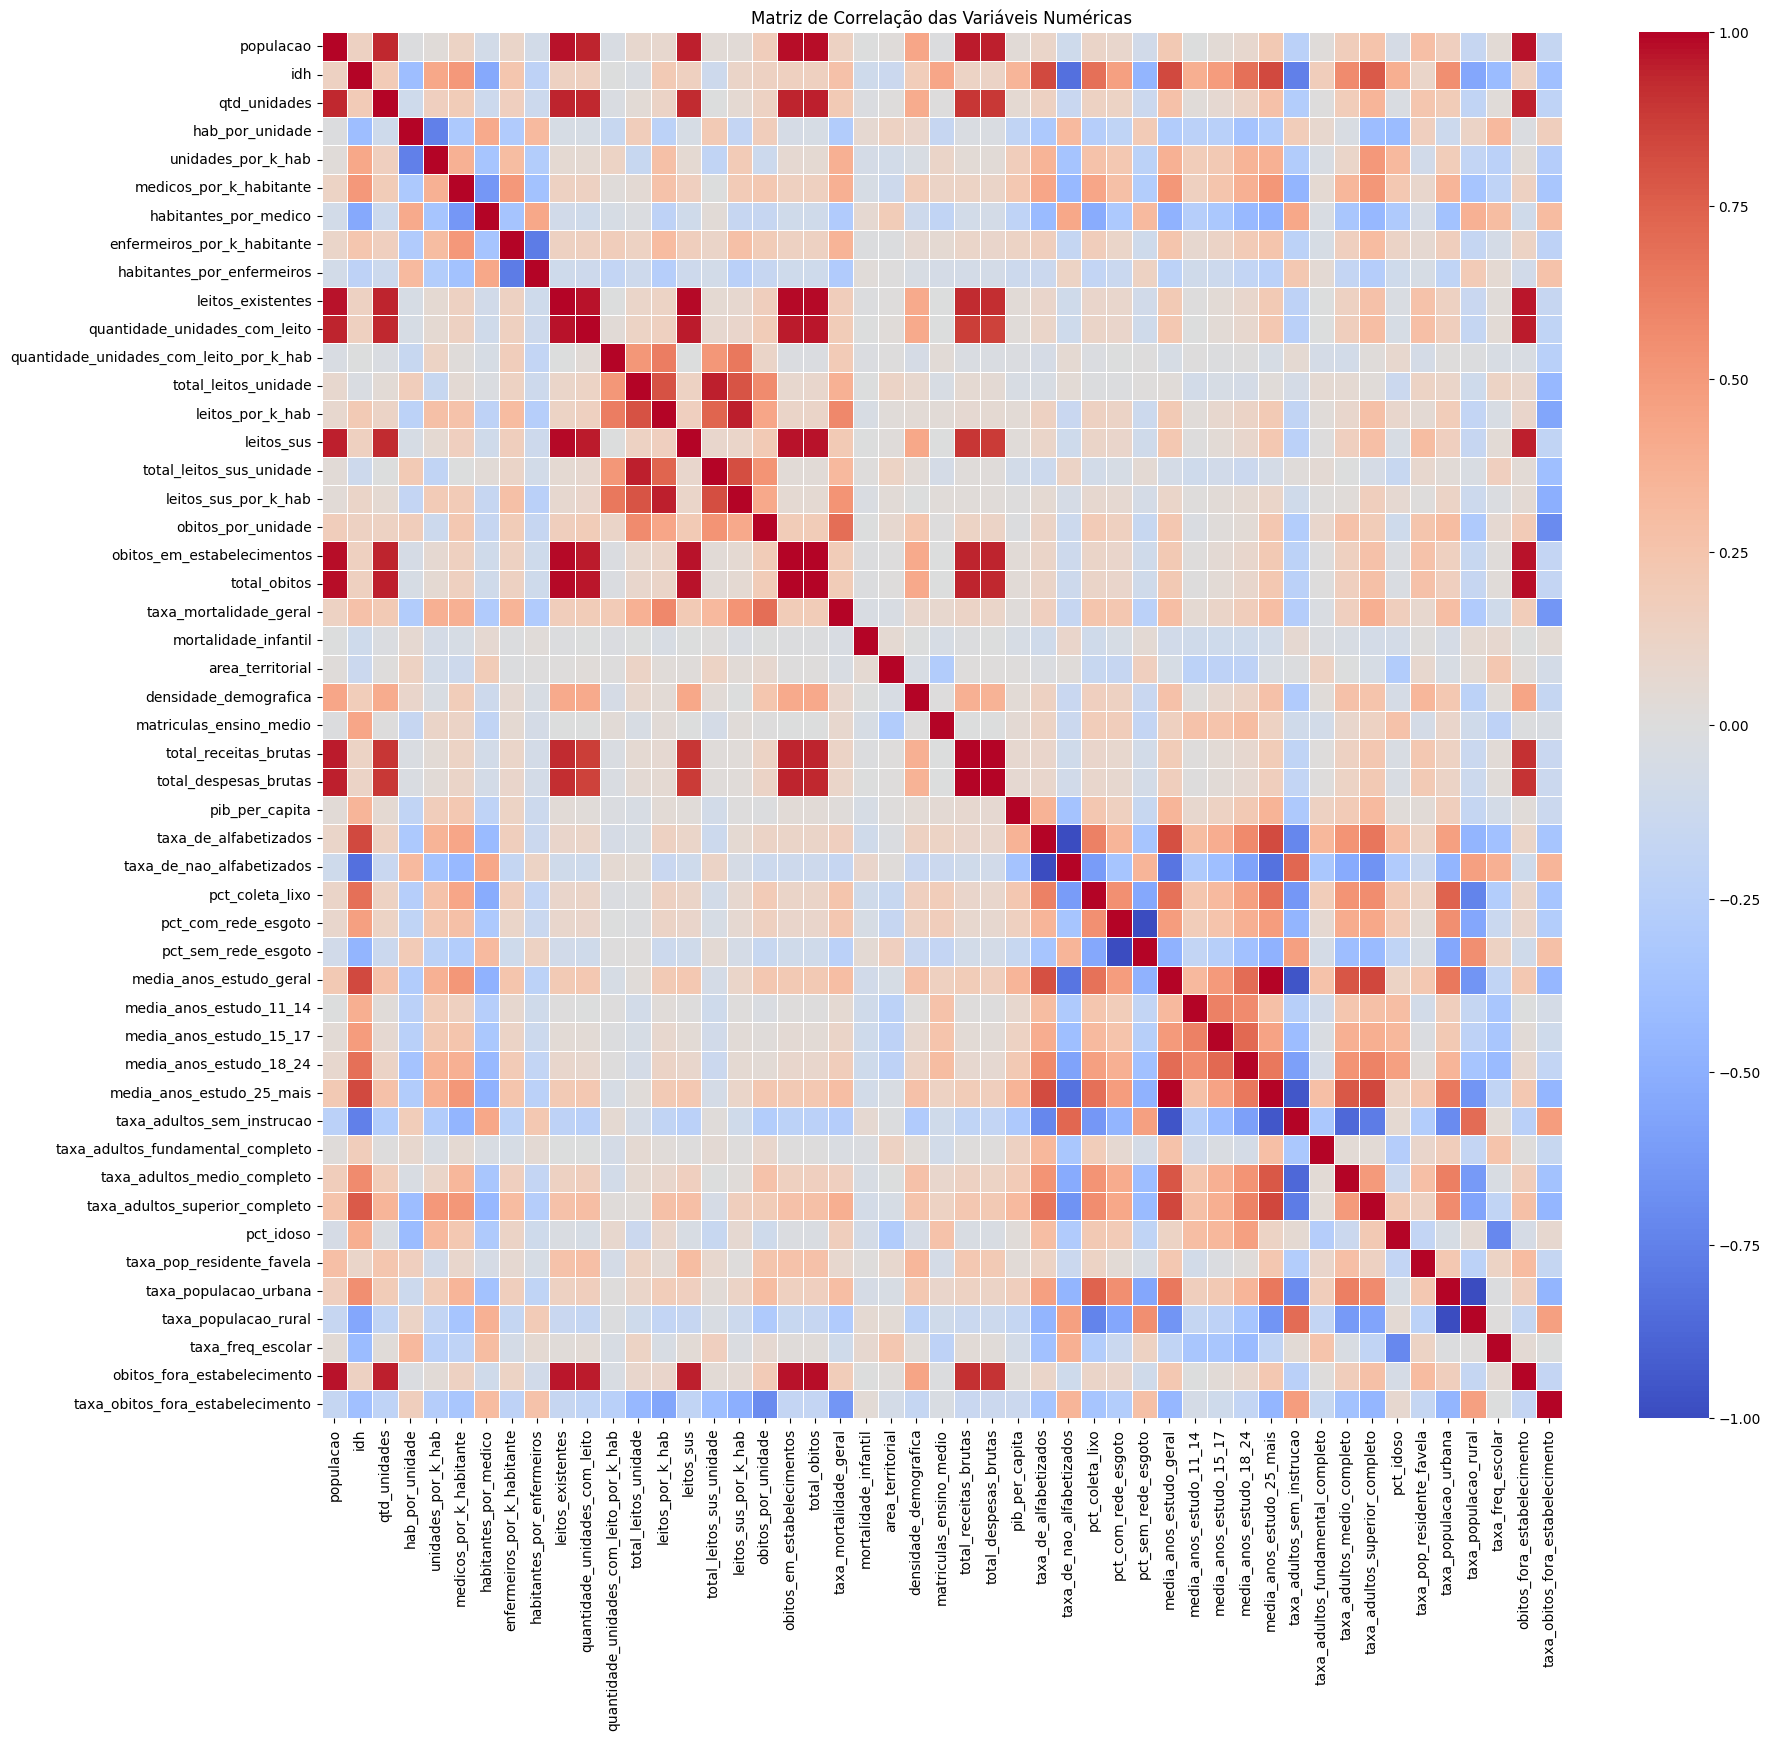

In [16]:
# --- Matriz de Correlação --- 
print("\n--- Calculando e Plotando Matriz de Correlação ---")

# Selecionar apenas colunas numéricas para correlação
numeric_cols = df.select_dtypes(include=['float64', 'int64', 'Int64']).columns
correlation_matrix = df[numeric_cols].corr()

# Plotar a matriz de correlação
plt.figure(figsize=(20, 18))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title("Matriz de Correlação das Variáveis Numéricas")
plt.show()
plt.close()

In [ ]:
# --- Seleção de Variáveis para Análise Detalhada ---
health_infra_vars = ['qtd_unidades', 'hab_por_unidade', 'medicos_por_k_habitante', 'enfermeiros_por_k_habitante', 'leitos_por_k_hab', 'leitos_sus_por_k_hab']
health_outcome_vars = ['taxa_mortalidade_geral', 'mortalidade_infantil', 'obitos_em_estabelecimentos']
socioeconomic_vars = ['idh', 'pib_per_capita', 'taxa_de_alfabetizados', 'pct_com_rede_esgoto', 'media_anos_estudo_geral']
demographic_vars = ['populacao', 'densidade_demografica', 'pct_idoso']

all_selected_vars = health_infra_vars + health_outcome_vars + socioeconomic_vars + demographic_vars

# --- Geração de Histogramas e Boxplots para variáveis selecionadas ---
print("\n--- Gerando Histogramas e Boxplots ---")
for col in all_selected_vars:
    if col in df.columns and df[col].dtype in ['float64', 'int64', 'Int64']:
        plt.figure(figsize=(12, 5))
        
        # Histograma
        plt.subplot(1, 2, 1)
        sns.histplot(df[col].dropna(), kde=True, bins=30)
        plt.title(f"Distribuição de {col}")
        plt.xlabel(col)
        plt.ylabel("Frequência")
        plt.grid(True)
        plt.show()
        
        # Boxplot
        plt.subplot(1, 2, 2)
        sns.boxplot(x=df[col].dropna())
        plt.title(f"Boxplot de {col}")
        plt.xlabel(col)
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        plt.close()

    elif col not in df.columns:
        print(f"Atenção: Coluna {col} não encontrada no DataFrame.")
    else:
        print(f"Atenção: Coluna {col} não é numérica, pulando histograma/boxplot.")

In [ ]:
print("\n--- Gerando Scatter Plots Selecionados (Plotly) ---")
scatter_pairs = [
    ('idh', 'medicos_por_k_habitante'),
    ('pib_per_capita', 'taxa_mortalidade_geral'),
    ('medicos_por_k_habitante', 'taxa_mortalidade_geral'),
    ('leitos_por_k_hab', 'taxa_mortalidade_geral'),
    ('pct_com_rede_esgoto', 'mortalidade_infantil')
]

for x_col, y_col in scatter_pairs:
    if (
        x_col in df.columns and y_col in df.columns and
        df[x_col].dtype in ['float64', 'int64', 'Int64'] and
        df[y_col].dtype in ['float64', 'int64', 'Int64']
    ):
        fig = px.scatter(
            df,
            x=x_col,
            y=y_col,
            hover_name='nome',
            hover_data={'uf': True},
            title=f"{y_col} vs. {x_col}",
            labels={x_col: x_col, y_col: y_col},
            opacity=0.6,
            template="plotly_white"
        )
        fig.show()
    else:
        print(f"Não foi possível gerar scatter plot para {y_col} vs. {x_col} (colunas ausentes ou não numéricas).")


### Feature Engineering

In [42]:
# Armazenando colunas categóricas
colunas_categoricas = df.select_dtypes(include=object).copy()
nome_colunas_categoricas = colunas_categoricas.columns.tolist()

# Dropando colunas categóricas do DataFrame
df = df.drop(columns=nome_colunas_categoricas)

# Padronizando os dados
scaler = StandardScaler()
df_padronizado = scaler.fit_transform(df)
df_padronizado = pd.DataFrame(df_padronizado, columns=df.columns)

In [44]:
# Verificando se há valores ausentes após a padronização
for col in df_padronizado.columns:
    if df_padronizado[col].isnull().sum() > 0:
        print(f"A coluna {col} possui valores ausentes após a padronização.")
    elif df_padronizado[col].isna().sum() > 0:
        print(f"A coluna {col} possui valores 'NaN' após a padronização.")
    elif df_padronizado[col].isnull().sum() > 0:
        print(f"A coluna {col} possui valores 'null' após a padronização.")

A coluna taxa_obitos_fora_estabelecimento possui valores ausentes após a padronização.


In [45]:
df_padronizado['taxa_obitos_fora_estabelecimento'].value_counts(normalize=True)

taxa_obitos_fora_estabelecimento
 1.398166    0.166217
-0.437217    0.014031
 0.174577    0.014031
 0.480474    0.010434
 0.990303    0.007735
               ...   
 0.884259    0.000180
-0.049934    0.000180
-0.785469    0.000180
-0.636234    0.000180
 0.182225    0.000180
Name: proportion, Length: 2479, dtype: float64

In [46]:
# Analisando valores ausentes encontrados
df_padronizado[
    df_padronizado['taxa_obitos_fora_estabelecimento'].isnull()
]

,populacao,idh,qtd_unidades,hab_por_unidade,unidades_por_k_hab,medicos_por_k_habitante,habitantes_por_medico,enfermeiros_por_k_habitante,habitantes_por_enfermeiros,leitos_existentes,quantidade_unidades_com_leito,quantidade_unidades_com_leito_por_k_hab,total_leitos_unidade,leitos_por_k_hab,leitos_sus,total_leitos_sus_unidade,leitos_sus_por_k_hab,obitos_por_unidade,obitos_em_estabelecimentos,total_obitos,taxa_mortalidade_geral,mortalidade_infantil,area_territorial,densidade_demografica,matriculas_ensino_medio,total_receitas_brutas,total_despesas_brutas,pib_per_capita,taxa_de_alfabetizados,taxa_de_nao_alfabetizados,pct_coleta_lixo,pct_com_rede_esgoto,pct_sem_rede_esgoto,media_anos_estudo_geral,media_anos_estudo_11_14,media_anos_estudo_15_17,media_anos_estudo_18_24,media_anos_estudo_25_mais,taxa_adultos_sem_instrucao,taxa_adultos_fundamental_completo,taxa_adultos_medio_completo,taxa_adultos_superior_completo,pct_idoso,taxa_pop_residente_favela,taxa_populacao_urbana,taxa_populacao_rural,taxa_freq_escolar,obitos_fora_estabelecimento,taxa_obitos_fora_estabelecimento
242,-0.163955,1.144955,-0.174998,0.067033,-0.636448,-0.470582,0.055926,0.327829,-0.629726,-0.130026,-0.203660,-0.755502,-0.839015,-0.818206,-0.162523,-0.824960,-0.817193,-0.881438,-0.129706,-0.147352,-1.701275,-0.960061,-0.218383,-0.180475,0.215524,-0.121570,-0.109799,0.850230,0.793738,-0.793738,0.893338,1.137717,-1.137726,1.203937,-1.158144,1.506844,1.186578,1.147807,-1.151588,-1.341281,2.075736,0.445761,0.043094,-0.230491,1.158369,-1.158370,-0.416889,-0.21583,NaN
2467,-0.167857,1.185157,-0.164510,-1.320270,2.169206,-0.330304,-0.150846,0.708927,-0.852805,-0.130026,-0.203660,-0.755502,-0.839015,-0.818206,-0.162523,-0.824960,-0.817193,-0.881438,-0.129706,-0.147352,-1.701275,-0.960061,-0.251629,-0.168760,0.266220,-0.125179,-0.111085,0.784626,0.907487,-0.907487,0.170768,1.117627,-1.117636,0.754324,1.420062,0.935792,0.537482,0.781054,-0.025904,-1.576368,0.357284,0.539662,2.238543,-0.230491,-1.008923,1.008922,-1.334196,-0.21583,NaN
2892,-0.164143,-0.932162,-0.167132,-0.770909,0.579164,0.082922,-0.525838,0.853466,-0.922256,-0.130026,-0.203660,-0.755502,-0.839015,-0.818206,-0.162523,-0.824960,-0.817193,-0.881438,-0.129706,-0.147352,-1.701275,1.362285,-0.252294,-0.156340,0.114132,-0.126404,-0.112993,-0.474245,-0.921754,0.921754,0.691891,0.974765,-0.974773,-0.594517,-1.480420,-1.919470,-0.760709,-0.465906,1.123968,-0.737289,-0.929975,-0.710120,-0.324628,-0.230491,0.042442,-0.042443,1.634248,-0.21583,NaN
3340,-0.161049,-0.717750,-0.156644,-1.124252,1.380362,0.372422,-0.681813,-0.906083,1.085562,-0.128649,-0.074143,3.324131,-0.758069,-0.663779,-0.159940,-0.733624,-0.634416,-0.881438,-0.129706,-0.147352,-1.701275,-0.960061,-0.249760,-0.152172,0.418309,-0.126187,-0.114467,0.035779,-1.411139,1.411139,-0.924280,0.133221,-0.133224,-0.774362,1.097786,-0.206313,0.277844,-0.979360,0.303639,1.175956,-0.114974,-1.237756,-0.117920,-0.230491,-0.654329,0.654328,0.602859,-0.21583,NaN
4054,-0.168555,0.595524,-0.174998,-0.225727,0.040349,1.154185,-0.923337,0.193435,-0.533225,-0.130026,-0.203660,-0.755502,-0.839015,-0.818206,-0.162523,-0.824960,-0.817193,-0.881438,-0.129706,-0.147352,-1.701275,-0.960061,-0.254274,-0.167298,0.519701,-0.128504,-0.113611,0.302552,0.892938,-0.892938,0.928347,-0.869043,0.869604,0.574478,1.097786,1.316493,1.056759,0.561002,-0.224435,-0.834940,0.905357,-0.267442,0.872099,-0.230491,-0.423396,0.423396,-0.845276,-0.21583,NaN
4062,-0.168158,1.747988,-0.172376,-0.571450,0.542411,1.567446,-0.998844,3.697683,-1.582043,-0.130026,-0.203660,-0.755502,-0.839015,-0.818206,-0.162523,-0.824960,-0.817193,-0.881438,-0.129706,-0.147352,-1.701275,-0.960061,-0.247478,-0.173920,0.747833,-0.124548,-0.113499,1.529386,1.377032,-1.377032,0.844555,1.065170,-1.065178,1.653551,-0.835868,0.745441,1.446216,1.587911,-1.329964,0.615364,0.946423,1.214857,2.016605,-0.230491,-0.210839,0.210838,0.023139,-0.21583,NaN
4259,-0.172540,0.247104,-0.169754,-1.359697,4.335179,-0.802440,0.961426,0.933310,-0.957765,-

In [47]:
df_padronizado['taxa_obitos_fora_estabelecimento'] = df_padronizado['taxa_obitos_fora_estabelecimento'].fillna(df_padronizado['taxa_obitos_fora_estabelecimento'].mean())

c:\Users\guilh\OneDrive\MBA\projeto_tcc\.venv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\guilh\OneDrive\MBA\projeto_tcc\.venv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\guilh\OneDrive\MBA\projeto_tcc\.venv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\guilh\OneDrive\MBA\projeto_tcc\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


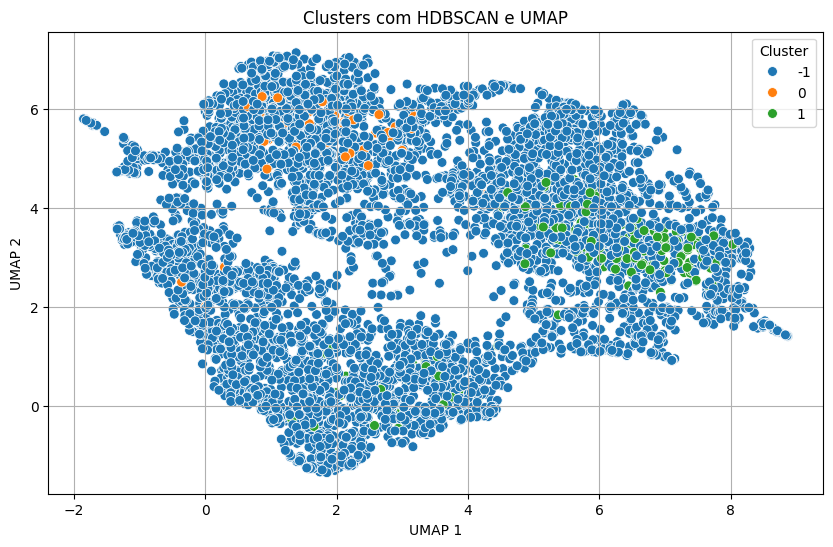

In [48]:
# Clusterizacao com HDBSCAN
clusterer = hdbscan.HDBSCAN(min_cluster_size=15, prediction_data=True)
clusters = clusterer.fit_predict(df_padronizado)
df['cluster'] = clusters

# Redução de Dimensionalidade com UMAP
reducer = umap.UMAP(random_state=42)
embedding = reducer.fit_transform(df_padronizado)

# Visualização
plt.figure(figsize=(10, 6))
sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1], hue=clusters, palette='tab10', s=50)
plt.title('Clusters com HDBSCAN e UMAP')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

In [51]:
df_clusterizado = pd.concat([colunas_categoricas, df], axis=1)

In [62]:
for cluster in df_clusterizado['cluster'].unique():
    print(f"Cluster {cluster}:")
    # print(df_clusterizado[df_clusterizado['cluster'] == cluster].nome)
    print(df_clusterizado[df_clusterizado['cluster'] == cluster].describe())
    print("\n" + "-"*100 + "\n")

Cluster -1:
          populacao          idh  qtd_unidades  hab_por_unidade  \
count  5.295000e+03  5295.000000   5295.000000      5295.000000   
mean   3.654820e+04     0.656481     68.622663       636.764115   
std    2.117053e+05     0.074514    390.418351       342.784253   
min    8.330000e+02     0.000000      1.000000        73.890000   
25%    5.038000e+03     0.597500      8.000000       391.365000   
50%    1.065600e+04     0.662000     15.000000       562.600000   
75%    2.376850e+04     0.715000     33.000000       799.780000   
max    1.145200e+07     0.862000  17429.000000      3373.800000   

       unidades_por_k_hab  medicos_por_k_habitante  habitantes_por_medico  \
count         5295.000000              5295.000000            5295.000000   
mean             1.748357                 2.922668             509.078710   
std              0.969899                 2.198987             350.141161   
min              0.234082                 0.214202              18.616667   